# Regression

## *Workshop 7*  [![Open In Colab](https://github.com/oballinger/BASC0005/blob/main/colab-badge.png?raw=1)](https://colab.research.google.com/github/oballinger/BASC0005/blob/main/notebooks/W07.%20Linear%20Regression.ipynb)

This workshop follows the structure of the lecture. We start with two continuous variables measured from very different places -- **light at night seen from space** and **GDP per capita** -- and use them to build ordinary least squares (OLS) from the ground up. We then ask how *uncertain* our estimates are (standard errors, confidence intervals, the bootstrap), check the **assumptions** of linear regression, and finally return to the Current Population Survey (CPS) to estimate the returns to schooling and the gender pay gap with control variables.

### Aims:

1. **Visualisation**: plotting the relationship between two continuous variables
2. **Ordinary Least Squares**
    * Fitting a line by hand and with `statsmodels`
    * Model fit: TSS, RSS and $R^2$
    * Interpreting coefficients (including log-transformed variables) and making predictions
3. **Standard errors and confidence intervals**
    * Analytic standard errors and 95% confidence intervals
    * The bootstrap
    * Coefficient plots
4. **Assumptions**
    * Anscombe's quartet: always plot your data
    * Normality of residuals, non-linearity, heteroskedasticity (and robust standard errors), independence
5. **Multiple regression on wages**: categorical variables, controls, and what "controlling for" means
6. **Spot the problem**: critiquing a flawed regression analysis

The core path (Sections 1-6) should take about two hours. Sections marked *(Optional)* are extensions.

## Getting Started

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (8, 5)
rng = np.random.default_rng(42)  # random number generator for the bootstrap (fixed seed = reproducible)

## 1. Visualisation: nighttime lights and GDP

In many countries official GDP statistics are unreliable, delayed, or politically manipulated. Economists have therefore turned to satellite images of **light at night** as an independent proxy for economic activity: richer places burn more electricity after dark. The lecture showed this for regions; here we do it for countries.

The dataset below combines:

* **Nighttime lights**: the sum of light brightness within each country's borders in 2022, from the harmonised DMSP/VIIRS global nighttime light series (Li et al. 2020, *Scientific Data*, [figshare](https://doi.org/10.6084/m9.figshare.9828827), CC BY 4.0), aggregated to [Natural Earth](https://www.naturalearthdata.com/) country borders.
* **GDP per capita** (PPP, constant 2021 international $) and **population** from the [World Bank API](https://data.worldbank.org/).

One caveat worth remembering: the light values are on the old DMSP satellite scale, which is **top-coded** at 63 -- the centre of a big city is recorded as "63" no matter how bright it really is. Very dense, bright places (think Singapore) therefore look dimmer than they are.

Columns: `sum_lights` (total brightness), `lit_share` (share of the country's land that is lit at all), `area_km2`, `gdp_pc`, `population`, and `lights_pc` = `sum_lights / population` (light per person).

In [2]:
nl = pd.read_csv("https://storage.googleapis.com/qm2/2627/w07/nightlights_gdp.csv")
print(nl.shape)
nl.sort_values("gdp_pc", ascending=False).head()

(183, 10)


,iso3,country,continent,sum_lights,lit_share,area_km2,gdp_pc,population,lights_pc,year
144,SGP,Singapore,Asia,35408.0,1.0000,486.0,134828.0,5637022.0,0.006281,2022
95,LUX,Luxembourg,Europe,105042.0,0.9998,2620.0,132570.8,653103.0,0.160835,2022
77,IRL,Ireland,Europe,706449.0,0.4549,68853.0,123007.5,5212836.0,0.135521,2022
133,QAT,Qatar,Asia,491163.0,0.9823,11098.0,114740.1,2657333.0,0.184833,2022
121,NOR,Norway,Europe,4189372.0,0.2748,323572.0,95109.8,5457127.0,0.767688,2022


Before fitting anything, **plot the data**. Both variables are measured per person, so large and small countries are comparable.

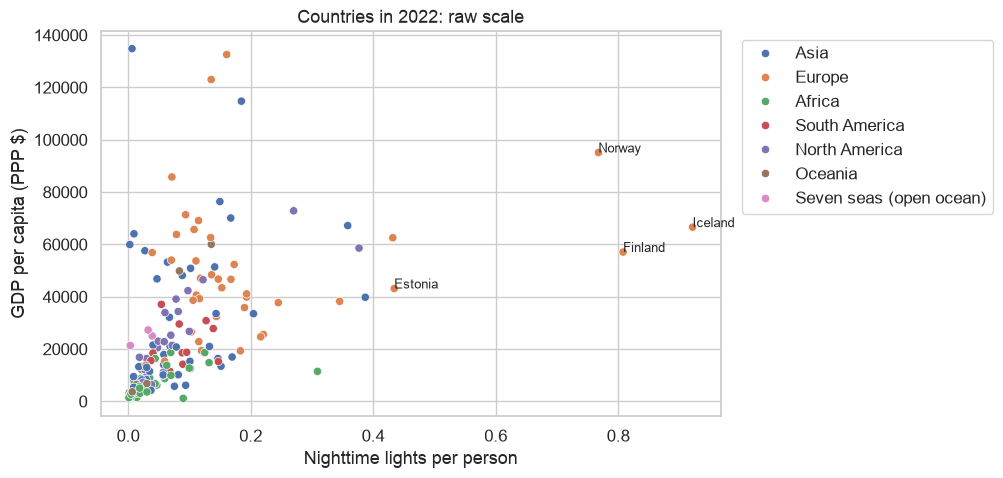

In [3]:
fig, ax = plt.subplots()
sns.scatterplot(data=nl, x="lights_pc", y="gdp_pc", hue="continent", ax=ax)
for _, r in nl.nlargest(4, "lights_pc").iterrows():
    ax.annotate(r["country"], (r["lights_pc"], r["gdp_pc"]), fontsize=9)
ax.set(xlabel="Nighttime lights per person", ylabel="GDP per capita (PPP $)",
       title="Countries in 2022: raw scale")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

Most countries are squashed into the bottom-left corner, and a handful of rich, bright countries dominate the picture. Both variables are **right-skewed** (a few very large values), which is typical of money and of light. Taking logs spreads out the bottom of the distribution:

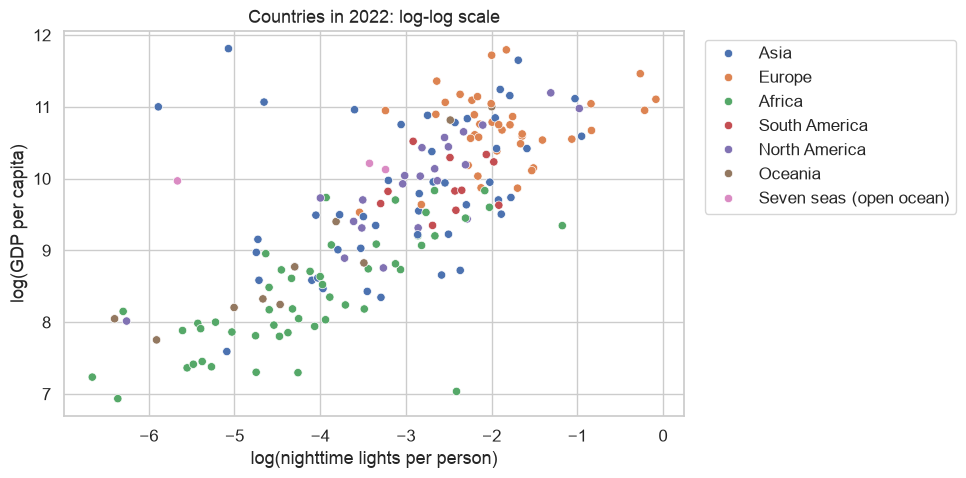

In [4]:
nl["log_lights_pc"] = np.log(nl["lights_pc"])
nl["log_gdp_pc"] = np.log(nl["gdp_pc"])

fig, ax = plt.subplots()
sns.scatterplot(data=nl, x="log_lights_pc", y="log_gdp_pc", hue="continent", ax=ax)
ax.set(xlabel="log(nighttime lights per person)", ylabel="log(GDP per capita)",
       title="Countries in 2022: log-log scale")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

On the log-log scale the relationship looks roughly **linear**, and positive: brighter countries (per person) tend to be richer. That is what OLS will summarise.

### Exercise 1

1. Make a scatterplot of `lit_share` (x) against `log_gdp_pc` (y), coloured by continent.
2. Which countries are far *above* the cloud of points (rich for how bright they are) and which are far *below*? Can you think of reasons (e.g. gas flaring, fishing fleets, conflict, city-states, high latitudes)?

In [5]:
# your code here

## 2. Ordinary Least Squares

OLS finds the straight line $\hat{y} = \hat\beta_0 + \hat\beta_1 x$ that makes the **sum of squared residuals** as small as possible, where a residual is $e_i = y_i - \hat{y}_i$ (the vertical distance from a point to the line).

For one predictor the solution has a closed form:

$$\hat\beta_1 = \frac{\sum_i (x_i-\bar x)(y_i-\bar y)}{\sum_i (x_i-\bar x)^2}, \qquad \hat\beta_0 = \bar y - \hat\beta_1 \bar x$$

Let's compute it by hand first, so there is nothing magic about what `statsmodels` does.

In [6]:
x = nl["log_lights_pc"]
y = nl["log_gdp_pc"]

b1 = ((x - x.mean()) * (y - y.mean())).sum() / ((x - x.mean())**2).sum()
b0 = y.mean() - b1 * x.mean()
print(f"By hand: intercept = {b0:.3f}, slope = {b1:.3f}")

By hand: intercept = 11.561, slope = 0.633


Now the same thing with `statsmodels`. The formula `"y ~ x"` means "regress y on x"; an intercept is added automatically.

In [7]:
m_log = smf.ols("log_gdp_pc ~ log_lights_pc", data=nl).fit()
print(m_log.summary())

                            OLS Regression Results                            
Dep. Variable:             log_gdp_pc   R-squared:                       0.538
Model:                            OLS   Adj. R-squared:                  0.535
Method:                 Least Squares   F-statistic:                     210.5
Date:                Tue, 29 Sep 2026   Prob (F-statistic):           3.83e-32
Time:                        14:57:21   Log-Likelihood:                -215.56
No. Observations:                 183   AIC:                             435.1
Df Residuals:                     181   BIC:                             441.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        11.5611      0.148     78.106

The coefficients match our hand calculation. Let's draw the fitted line and the residuals:

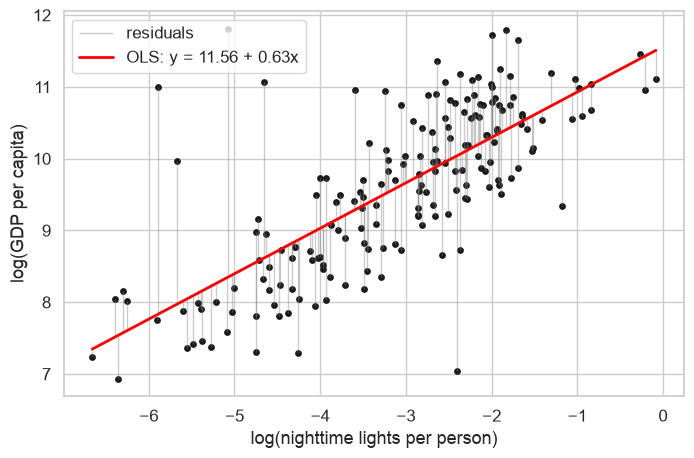

In [8]:
nl["fitted"] = m_log.fittedvalues
nl["resid"] = m_log.resid

fig, ax = plt.subplots()
ax.vlines(nl["log_lights_pc"], nl["fitted"], nl["log_gdp_pc"], color="grey", alpha=0.4, lw=1, label="residuals")
ax.scatter(nl["log_lights_pc"], nl["log_gdp_pc"], s=15, color="k")
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, b0 + b1 * xs, color="red", lw=2, label=f"OLS: y = {b0:.2f} + {b1:.2f}x")
ax.set(xlabel="log(nighttime lights per person)", ylabel="log(GDP per capita)")
ax.legend()
plt.show()

### 2.1 Model fit: $R^2$

How much better is the line than just guessing the mean $\bar y$ for every country?

* **TSS** (total sum of squares) $= \sum (y_i - \bar y)^2$: total variability in $y$.
* **RSS** (residual sum of squares) $= \sum (y_i - \hat y_i)^2$: variability left over after fitting the line.
* $R^2 = 1 - \dfrac{RSS}{TSS}$: the share of the variability in $y$ that the model accounts for.

In [9]:
TSS = ((y - y.mean())**2).sum()
RSS = (m_log.resid**2).sum()
print(f"TSS = {TSS:.1f}, RSS = {RSS:.1f}, R^2 = 1 - RSS/TSS = {1 - RSS/TSS:.3f}")
print(f"statsmodels R^2 = {m_log.rsquared:.3f}")

TSS = 244.4, RSS = 113.0, R^2 = 1 - RSS/TSS = 0.538
statsmodels R^2 = 0.538


### 2.2 Interpreting the coefficients

Both variables are in logs, so the slope is an **elasticity**: a 1% increase in $x$ is associated with a $\hat\beta_1$% change in $y$.

In [10]:
b1 = m_log.params["log_lights_pc"]
print(f"A country with 10% more light per person has, on average, about {b1*10:.1f}% higher GDP per capita.")

A country with 10% more light per person has, on average, about 6.3% higher GDP per capita.


Be careful with the words. This is an **association across countries**, not the effect of switching on more street lights. Lights don't cause GDP; both are driven by electrification, industry, urbanisation, and so on.

The general rules for log transformations (for small coefficients):

| Model | Interpretation of $\hat\beta_1$ |
|---|---|
| $y = \beta_0 + \beta_1 x$ | 1-unit increase in $x$ → $\beta_1$-unit change in $y$ |
| $\log y = \beta_0 + \beta_1 x$ | 1-unit increase in $x$ → approx. $100\beta_1$% change in $y$ (exactly $100(e^{\beta_1}-1)$%) |
| $y = \beta_0 + \beta_1 \log x$ | 1% increase in $x$ → $\beta_1/100$-unit change in $y$ |
| $\log y = \beta_0 + \beta_1 \log x$ | 1% increase in $x$ → $\beta_1$% change in $y$ |

### 2.3 Making predictions

A regression line can be used to predict $y$ for a new value of $x$. `get_prediction()` returns the prediction together with two kinds of interval:

* a **confidence interval** for the *average* $y$ at that $x$ (uncertainty about where the line is), and
* a **prediction interval** for an *individual* country (line uncertainty + the scatter of points around the line), which is much wider.

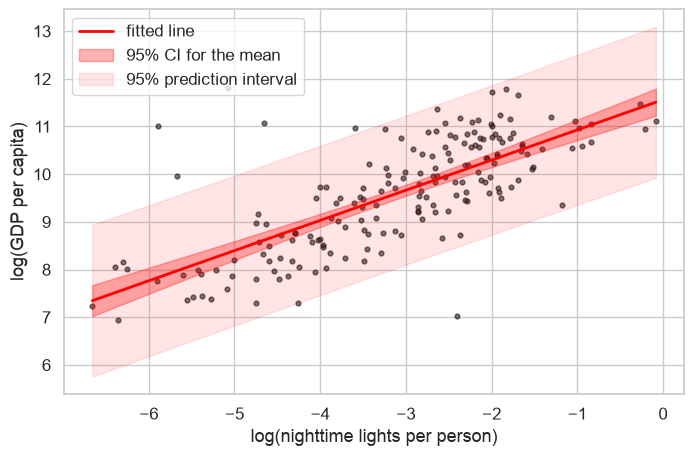

In [11]:
grid = pd.DataFrame({"log_lights_pc": np.linspace(x.min(), x.max(), 100)})
pred = m_log.get_prediction(grid).summary_frame(alpha=0.05)

fig, ax = plt.subplots()
ax.scatter(nl["log_lights_pc"], nl["log_gdp_pc"], s=12, color="k", alpha=0.6)
ax.plot(grid["log_lights_pc"], pred["mean"], color="red", lw=2, label="fitted line")
ax.fill_between(grid["log_lights_pc"], pred["mean_ci_lower"], pred["mean_ci_upper"], color="red", alpha=0.3, label="95% CI for the mean")
ax.fill_between(grid["log_lights_pc"], pred["obs_ci_lower"], pred["obs_ci_upper"], color="red", alpha=0.1, label="95% prediction interval")
ax.set(xlabel="log(nighttime lights per person)", ylabel="log(GDP per capita)")
ax.legend()
plt.show()

### Exercise 2

1. Pick a country (e.g. `"Nigeria"`). Use `m_log.get_prediction()` to predict its log GDP per capita from its lights, convert the prediction and its 95% prediction interval back to dollars with `np.exp()`, and compare with the actual value. Is the country richer or poorer than its lights suggest?
2. Interpret the $R^2$ of `m_log` in one sentence. Would you trust this model to estimate GDP for a country with no official statistics? What would make you more or less confident?

In [12]:
country = nl[nl["country"] == "Nigeria"]
# your code here

## 3. Standard errors and confidence intervals

Our 183 countries are one "realisation" of the world. If the data had come out slightly differently (different measurement error, a different year) we would have got a slightly different line. The **standard error** (SE) of a coefficient measures how much $\hat\beta$ would vary across such realisations.

`statsmodels` computes an **analytic** SE from a formula. A 95% confidence interval is roughly $\hat\beta \pm 1.96 \times SE$ (with small samples, a $t$ critical value instead of 1.96):

In [13]:
se = m_log.bse["log_lights_pc"]
ci = m_log.conf_int(alpha=0.05).loc["log_lights_pc"]
print(f"slope = {b1:.3f}, SE = {se:.4f}")
print(f"95% CI by hand: [{b1 - 1.96*se:.3f}, {b1 + 1.96*se:.3f}]")
print(f"95% CI from statsmodels: [{ci[0]:.3f}, {ci[1]:.3f}]")

slope = 0.633, SE = 0.0436
95% CI by hand: [0.547, 0.718]
95% CI from statsmodels: [0.547, 0.719]


### 3.1 The bootstrap

The analytic formula relies on assumptions (Section 4). The **bootstrap** estimates the same sampling variability by brute force:

1. Draw a sample of 183 countries **with replacement** from our 183 countries (some appear twice, some not at all).
2. Fit the regression on this bootstrap sample and store the slope.
3. Repeat many times. The standard deviation of the stored slopes is the bootstrap SE; the 2.5th and 97.5th percentiles give a 95% confidence interval.

In [14]:
n_boot = 1000
boot_slopes, boot_intercepts = [], []
for i in range(n_boot):
    sample = nl.sample(n=len(nl), replace=True, random_state=rng)
    fit = smf.ols("log_gdp_pc ~ log_lights_pc", data=sample).fit()
    boot_intercepts.append(fit.params["Intercept"])
    boot_slopes.append(fit.params["log_lights_pc"])
boot_slopes = np.array(boot_slopes)

print(f"analytic SE  = {se:.4f}")
print(f"bootstrap SE = {boot_slopes.std(ddof=1):.4f}")
print("bootstrap 95% CI:", np.percentile(boot_slopes, [2.5, 97.5]).round(3))

analytic SE  = 0.0436
bootstrap SE = 0.0502
bootstrap 95% CI: [0.53  0.727]


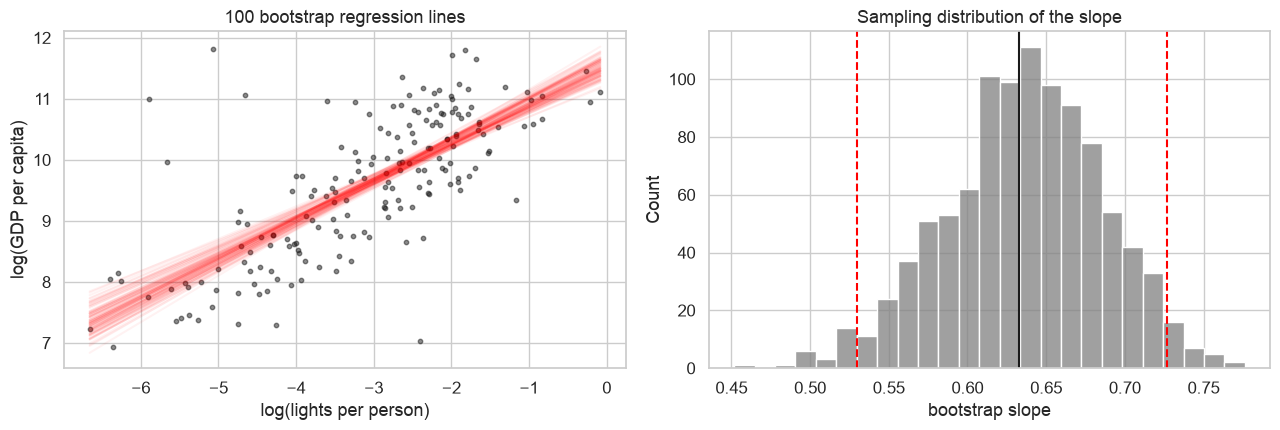

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# left: the first 100 bootstrap regression lines
axes[0].scatter(nl["log_lights_pc"], nl["log_gdp_pc"], s=10, color="k", alpha=0.5)
for a, b in zip(boot_intercepts[:100], boot_slopes[:100]):
    axes[0].plot(xs, a + b * xs, color="red", alpha=0.05)
axes[0].set(xlabel="log(lights per person)", ylabel="log(GDP per capita)", title="100 bootstrap regression lines")

# right: distribution of the bootstrap slopes
sns.histplot(boot_slopes, ax=axes[1], color="grey")
for q in np.percentile(boot_slopes, [2.5, 97.5]):
    axes[1].axvline(q, color="red", ls="--")
axes[1].axvline(b1, color="k")
axes[1].set(xlabel="bootstrap slope", title="Sampling distribution of the slope")
plt.tight_layout()
plt.show()

The two SEs are in the same ballpark, but the bootstrap one is somewhat larger. When the bootstrap and the formula disagree, that is a hint that the assumptions behind the formula (Section 4) don't fully hold -- keep this in mind.

### Exercise 3

1. Fit the **raw-scale** model `gdp_pc ~ lights_pc` and store it as `m_raw`. Report its slope, SE and 95% CI, and interpret the slope in words (careful with units: what is a one-unit change in `lights_pc`?).
2. Bootstrap the slope of `m_raw` (1000 replications). How does the bootstrap SE compare with the analytic SE? Keep your answer -- you'll explain it in Section 4.

In [16]:
# your code here

## 4. Assumptions

OLS will always give you a line. Whether the line (and its SEs) means anything depends on some assumptions:

1. **Linearity / normality of residuals**: the relationship is linear and the residuals are roughly normally distributed around zero.
2. **Homoskedasticity**: the spread of the residuals is the same for all values of $x$.
3. **Independence**: observations do not influence each other.

### 4.1 Anscombe's quartet: always plot your data

In 1973 Francis Anscombe built four small datasets that have (almost) identical means, variances, correlations and regression lines -- but look completely different.

In [17]:
anscombe = sns.load_dataset("anscombe")
anscombe.groupby("dataset").agg(x_mean=("x", "mean"), y_mean=("y", "mean"),
                                x_sd=("x", "std"), y_sd=("y", "std")).round(2)

,x_mean,y_mean,x_sd,y_sd
dataset,,,,
I,9.0,7.5,3.32,2.03
II,9.0,7.5,3.32,2.03
III,9.0,7.5,3.32,2.03
IV,9.0,7.5,3.32,2.03


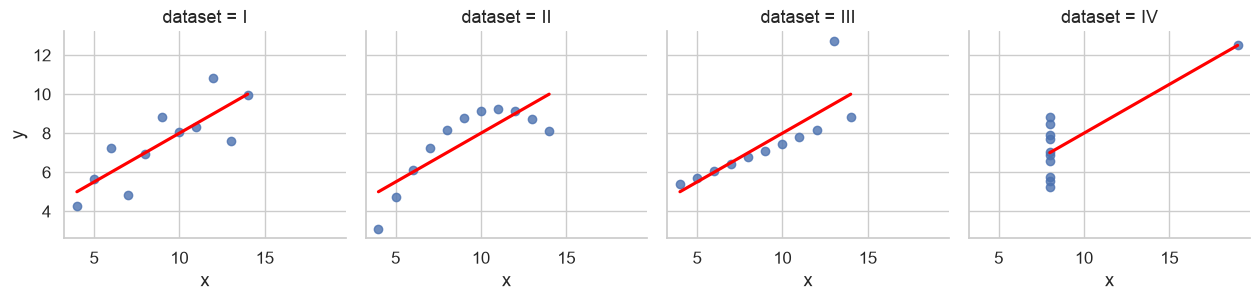

In [18]:
g = sns.lmplot(data=anscombe, x="x", y="y", col="dataset", col_wrap=4, ci=None,
               height=3.2, line_kws={"color": "red"})
plt.show()

All four have the regression line $y \approx 3 + 0.5x$ and $R^2 \approx 0.67$. Only dataset I is a sensible use of a straight line: II is curved, III has one outlier dragging the line, and IV's slope is determined entirely by a single point. **The regression table alone could not tell you this.**

### Exercise 4

1. For each of the four datasets, fit `y ~ x` and print the intercept, slope and $R^2$ (hint: loop over `anscombe["dataset"].unique()`). Confirm they are nearly identical.
2. For each one, plot the residuals against the fitted values. Which pattern would warn you about each problem (non-linearity, outlier, leverage) if you could not see the raw scatter?

In [19]:
for d in anscombe["dataset"].unique():
    sub = anscombe[anscombe["dataset"] == d]
    # your code here

### 4.2 Residual diagnostics: non-linearity and heteroskedasticity

With more than one predictor we can't plot everything against everything, so we plot the **residuals against the fitted values**. If the model is fine this looks like a shapeless horizontal cloud around zero. Let's compare the raw-scale and log-log nightlights models:

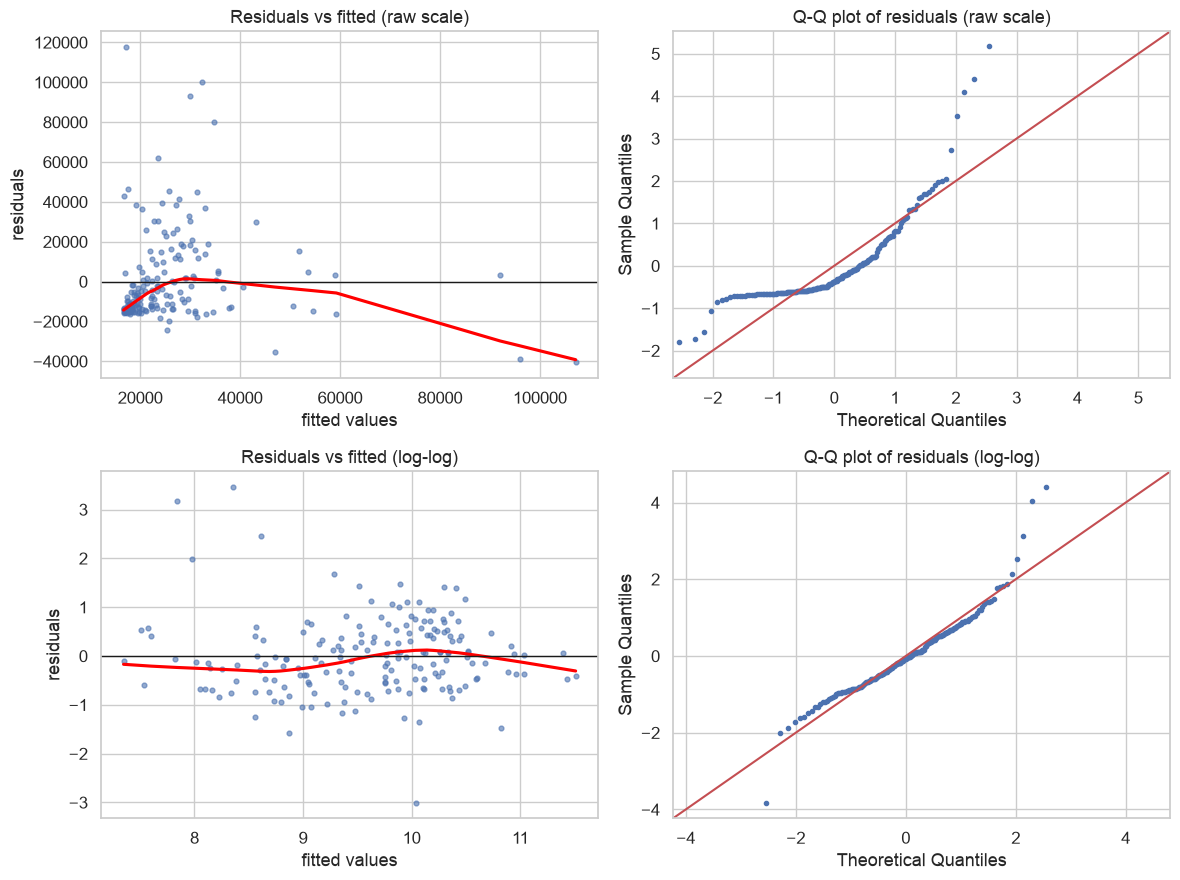

In [20]:
m_raw = smf.ols("gdp_pc ~ lights_pc", data=nl).fit()

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for row, (m, name) in enumerate([(m_raw, "raw scale"), (m_log, "log-log")]):
    sns.regplot(x=m.fittedvalues, y=m.resid, lowess=True, ax=axes[row, 0],
                scatter_kws={"s": 12, "alpha": 0.6}, line_kws={"color": "red"})
    axes[row, 0].axhline(0, color="k", lw=1)
    axes[row, 0].set(xlabel="fitted values", ylabel="residuals", title=f"Residuals vs fitted ({name})")
    sm.qqplot(m.resid, line="45", fit=True, ax=axes[row, 1], markersize=3)
    axes[row, 1].set_title(f"Q-Q plot of residuals ({name})")
plt.tight_layout()
plt.show()

Read the four panels:

* **Raw scale, residuals vs fitted**: the red smoother is not flat -- the line over-predicts at both the low and the high end (**non-linearity**) -- and the residuals are lopsided: a few enormous positive ones and many small negative ones. The spread is also uneven across fitted values (**heteroskedasticity**).
* **Raw scale, Q-Q plot**: the points bend away from the 45° line -- the residuals are strongly skewed, not normal.
* **Log-log**: much closer to a flat, even cloud, and the Q-Q plot follows the line apart from a few outlying countries in the tails. (Which countries are they? Use `nl.loc[nl["resid"].abs() > 2]`.)

Heteroskedasticity doesn't bias the coefficients, but it makes the usual (analytic) SE formula wrong. The standard fix is **heteroskedasticity-robust standard errors**, which `statsmodels` gives you with `cov_type="HC1"` (the same as Stata's `, robust`):

In [21]:
for m, name in [(m_raw, "raw"), (m_log, "log-log")]:
    rob = m.get_robustcov_results(cov_type="HC1")
    print(f"{name:8s} slope = {m.params.iloc[1]:10.3f} | classic SE = {m.bse.iloc[1]:9.3f} | robust SE = {rob.bse[1]:9.3f}")

raw      slope =  98342.446 | classic SE = 13282.122 | robust SE = 16858.529
log-log  slope =      0.633 | classic SE =     0.044 | robust SE =     0.049


For the raw-scale model the robust SE is noticeably different from the classic one; for the log-log model they are similar. Now look back at your answer to Exercise 3.2: which SE did your bootstrap agree with? (The bootstrap resamples whole observations, so it doesn't assume constant variance either.)

In practice many applied economists report robust SEs by default: `smf.ols(...).fit(cov_type="HC1")`.

### 4.3 Independence

OLS assumes each observation carries independent information. That is often doubtful:

* **Repeated observations of the same unit**: the CPS contains several survey years. If the same people or states appear repeatedly, their residuals are correlated, and naive SEs are too small. This needs a **panel regression** or **clustered standard errors** (next week).
* **Spatial dependence**: neighbouring countries share climate, trade and history, so their residuals are likely correlated too. Our 183 countries are not 183 independent experiments.

## 5. Multiple regression: schooling, gender and wages

We now return to the U.S. Current Population Survey (CPS) from last week's workshop. Each row is a worker. The columns are:

* `year`, `state` ([FIPS code](https://www.bls.gov/respondents/mwr/electronic-data-interchange/appendix-d-usps-state-abbreviations-and-fips-codes.htm)), `age`
* `sex`: 1 = male, 2 = female
* `race`: 1 = White non-Hispanic, 2 = Black non-Hispanic, 3 = Hispanic, 4 = Other non-Hispanic
* `sch`: years of schooling (12 = high school, 14 = associate's degree, 16 = BA, 18 = advanced degree)
* `union`: 0 = N/A, 1 = no union coverage, 2 = union member, 3 = covered but not a member
* `ind`: industry code; `occupation`: occupation group (`"."` = not recorded)
* `incwage`: annual wage and salary income; `realhrwage`: real hourly wage

In [22]:
df = pd.read_csv("https://storage.googleapis.com/qm2/wk7/cps.csv")

reg_df = df[df["year"] == 2013].drop(columns="year").copy()   # one cross-section: 2013
# drop extreme wage outliers: more than 3 IQRs beyond the quartiles
q1, q3 = reg_df["realhrwage"].quantile([0.25, 0.75])
iqr = q3 - q1
keep = reg_df["realhrwage"].between(q1 - 3*iqr, q3 + 3*iqr, inclusive="neither")
print(f"Dropped {(~keep).sum()} outliers; max hourly wage before = ${reg_df['realhrwage'].max():,.0f}")
reg_df = reg_df[keep]
reg_df["logwage"] = np.log(reg_df["realhrwage"])

reg_df[["age", "sch", "realhrwage", "logwage"]].describe().round(2).T

Dropped 1040 outliers; max hourly wage before = $34,761


,count,mean,std,min,25%,50%,75%,max
age,52750.0,42.84,10.57,25.00,34.00,43.00,51.00,64.00
sch,52750.0,13.88,2.73,0.00,12.00,13.00,16.00,18.00
realhrwage,52750.0,21.59,13.03,2.01,11.99,18.44,27.66,75.81
logwage,52750.0,2.90,0.60,0.70,2.48,2.91,3.32,4.33


Why logs? Wages are right-skewed, and schooling tends to raise wages by a roughly constant *percentage* rather than a constant number of dollars. Compare the two versions:

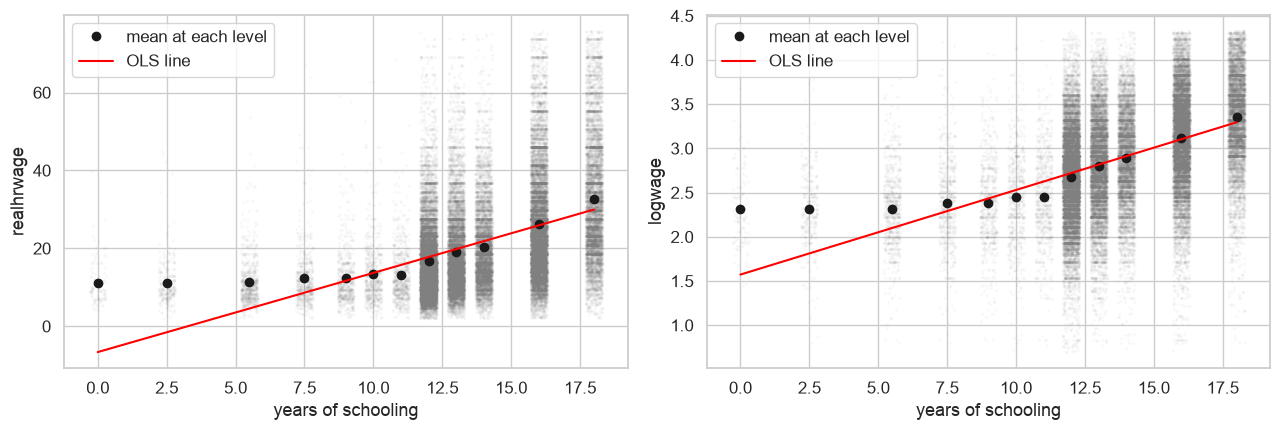

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, yvar in zip(axes, ["realhrwage", "logwage"]):
    means = reg_df.groupby("sch")[yvar].mean()
    ax.scatter(reg_df["sch"] + rng.uniform(-0.3, 0.3, len(reg_df)), reg_df[yvar], s=2, alpha=0.03, color="grey")
    ax.plot(means.index, means.values, "o", color="k", label="mean at each level")
    m = smf.ols(f"{yvar} ~ sch", data=reg_df).fit()
    ax.plot(means.index, m.params["Intercept"] + m.params["sch"] * means.index, color="red", label="OLS line")
    ax.set(xlabel="years of schooling", ylabel=yvar)
    ax.legend()
plt.tight_layout()
plt.show()

In [24]:
m_sch = smf.ols("logwage ~ sch", data=reg_df).fit(cov_type="HC1")
b = m_sch.params["sch"]
print(m_sch.summary().tables[1])
print(f"\nEach extra year of schooling is associated with {100*b:.1f} log points, i.e. {100*(np.exp(b)-1):.1f}% higher hourly wages.")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.5727      0.013    123.470      0.000       1.548       1.598
sch            0.0957      0.001    106.195      0.000       0.094       0.097

Each extra year of schooling is associated with 9.6 log points, i.e. 10.0% higher hourly wages.


Logging fixes the negative predicted wages of the raw-scale line, but look at the black dots on the right: even in logs, the means are **flat up to about 11 years and then climb steeply**, so a single straight line under-predicts at the bottom and misses the curvature. That is a non-linear relationship. (One fix is to add dummies for education levels, `C(sch)`, or a squared term, `I(sch**2)`; try it if you have time.)

### 5.1 Categorical variables

`sex`, `race`, `union`, `state` and `occupation` are stored as numbers or codes, but the numbers are just labels: "race = 4" is not twice "race = 2". Wrapping a variable in `C()` tells the formula to create a **dummy variable** for each category except one, the **reference category**, which is absorbed into the intercept. Each coefficient is then a comparison *with the reference category*.

Below, `C(sex)[T.2]` is the difference in log wages between women (2) and men (1, the reference). We can choose a different reference with `C(race, Treatment(reference=1))`.

In [25]:
m_gap = smf.ols("logwage ~ C(sex)", data=reg_df).fit(cov_type="HC1")
print(m_gap.summary().tables[1])
means = reg_df.groupby("sex")["logwage"].mean()
print(f"\nmean log wage, women minus men: {means[2] - means[1]:.4f}   <- the same number: a difference in group means")

                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       2.9975      0.004    827.320      0.000       2.990       3.005
C(sex)[T.2]    -0.1951      0.005    -38.061      0.000      -0.205      -0.185

mean log wage, women minus men: -0.1951   <- the same number: a difference in group means


### 5.2 What does "controlling for" mean?

The raw gap compares *all* women with *all* men. But men and women in the sample may differ in age, schooling, and occupation. Adding these as **controls** means the coefficient on sex compares men and women who have the *same* values of the controls.

We can see this happen by adding controls one step at a time and putting the results side by side in a **regression table**:

In [26]:
m1 = smf.ols("logwage ~ C(sex)", data=reg_df).fit(cov_type="HC1")
m2 = smf.ols("logwage ~ C(sex) + sch + age", data=reg_df).fit(cov_type="HC1")
m3 = smf.ols("logwage ~ C(sex) + sch + age + C(occupation)", data=reg_df).fit(cov_type="HC1")

print(summary_col([m1, m2, m3], stars=True, float_format="%0.3f",
                  model_names=["(1) raw", "(2) + school, age", "(3) + occupation"],
                  regressor_order=["C(sex)[T.2]", "sch", "age"], drop_omitted=True,
                  info_dict={"N": lambda r: f"{int(r.nobs)}"}))


                (1) raw  (2) + school, age (3) + occupation
-----------------------------------------------------------
C(sex)[T.2]    -0.195*** -0.248***         -0.203***       
               (0.005)   (0.005)           (0.005)         
sch                      0.100***          0.089***        
                         (0.001)           (0.001)         
age                      0.008***          0.008***        
                         (0.000)           (0.000)         
R-squared      0.027     0.251             0.300           
R-squared Adj. 0.027     0.251             0.300           
N              52750     52750             52750           
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


Robust standard errors are in parentheses; `*` p<0.1, `**` p<0.05, `***` p<0.01.

A useful way to see what a control does (the Frisch-Waugh-Lovell theorem): the coefficient on `sch` in model (2) is exactly the slope you get if you first remove from **both** log wages and schooling the part explained by age and sex, and then regress what is left over on what is left over. Controlling = comparing people after "netting out" the controls.

coefficient on sch in model (2): 0.1004
slope of residual on residual:   0.1004


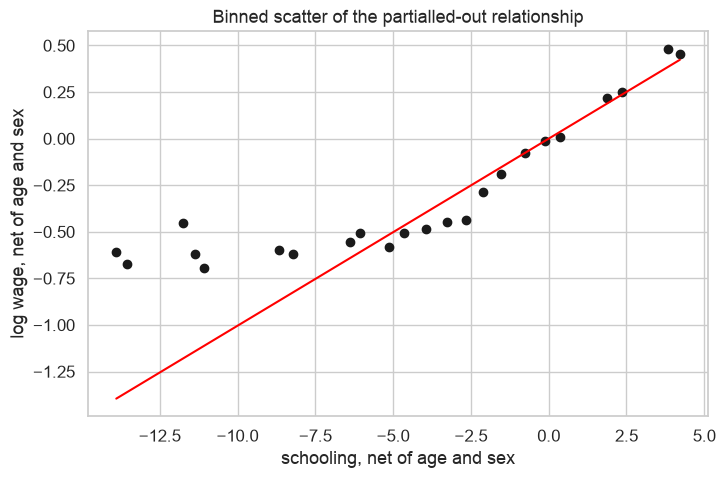

In [27]:
res_y = smf.ols("logwage ~ age + C(sex)", data=reg_df).fit().resid   # wages not explained by age & sex
res_x = smf.ols("sch ~ age + C(sex)", data=reg_df).fit().resid       # schooling not explained by age & sex
fwl_slope = np.polyfit(res_x, res_y, 1)[0]
print(f"coefficient on sch in model (2): {m2.params['sch']:.4f}")
print(f"slope of residual on residual:   {fwl_slope:.4f}")

bins = pd.cut(res_x, 30)
binned = pd.DataFrame({"x": res_x, "y": res_y}).groupby(bins, observed=True).mean()
plt.scatter(binned["x"], binned["y"], color="k")
plt.plot(binned["x"], fwl_slope * binned["x"], color="red")
plt.xlabel("schooling, net of age and sex")
plt.ylabel("log wage, net of age and sex")
plt.title("Binned scatter of the partialled-out relationship")
plt.show()

**Interpretation questions** (answer in a markdown cell):

1. How does the gender coefficient change between models (1), (2) and (3)? What does that tell you about how men and women in the sample differ?
2. Model (3) compares men and women *in the same occupation*. If women are steered into lower-paid occupations, is controlling for occupation the right thing to do when measuring discrimination? What question does model (3) answer, and what question does model (1) answer?
3. About 40% of the sample has occupation `"."`. How is that group treated in model (3)?

### 5.3 Coefficient plots

Regression tables get unreadable with many coefficients. A **coefficient plot** shows each estimate as a point with its 95% confidence interval; a coefficient whose interval crosses zero is not statistically significant at the 5% level.

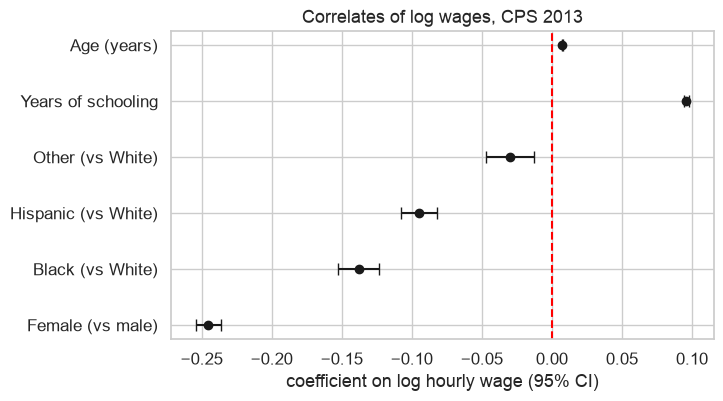

In [28]:
m_race = smf.ols("logwage ~ C(sex) + sch + age + C(race)", data=reg_df).fit(cov_type="HC1")

coefs = pd.DataFrame({"coef": m_race.params, "lo": m_race.conf_int()[0], "hi": m_race.conf_int()[1]}).drop("Intercept")
labels = {"C(sex)[T.2]": "Female (vs male)", "C(race)[T.2]": "Black (vs White)",
          "C(race)[T.3]": "Hispanic (vs White)", "C(race)[T.4]": "Other (vs White)",
          "sch": "Years of schooling", "age": "Age (years)"}
coefs.index = coefs.index.map(labels)

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(coefs["coef"], coefs.index, xerr=[coefs["coef"] - coefs["lo"], coefs["hi"] - coefs["coef"]],
            fmt="o", color="k", capsize=4)
ax.axvline(0, color="red", ls="--")
ax.set(xlabel="coefficient on log hourly wage (95% CI)", title="Correlates of log wages, CPS 2013")
plt.show()

Note that the coefficients are on different scales (one year of age vs being female), so the *length* of the bars is not a measure of importance. Coefficient plots work best when the predictors are comparable, e.g. a set of dummies for the same variable, or the same coefficient across several models.

### Exercise 5

1. Estimate the model below and store it as `model1`. Use robust standard errors.

$$\log(\text{wage}) = \beta_0 + \beta_1\,\text{schooling} + \beta_2\,\text{age} + \beta_3\,\text{sex} + \beta_4\,\text{union} + \beta_5\,\text{race} + \epsilon$$

2. Make a coefficient plot for the **union** categories only. Which category is the reference? Interpret the coefficient on "union member" as a percentage.
3. Comment on the overall fit ($R^2$). Does a low $R^2$ mean that schooling "doesn't matter" for wages?

In [29]:
# your code here

### Exercise 6 *(Optional)*

Run the model from Exercise 5 separately for five samples: the full sample, and the occupations `"Production"`, `"Farming, Fishing & Forestry"`, `"financial Operators"` and `"Lawyers, Judges,Physicans and dentists"` (the labels are spelt exactly like this in the data). Put the results in one table with `summary_col`, then plot the gender coefficient and its 95% CI for each sample in a single coefficient plot. How does the gender gap, and the union premium, vary across occupations?

In [30]:
samples = {"All": reg_df}
# your code here

## 6. Spot the problem

Below is a short analysis written by a (fictional) consultant. The code runs, the numbers are real, and the p-values are tiny -- but the **conclusions contain several mistakes**. Run the cell, read the report, and then list every problem you can find. For each, explain *why* it is wrong and what should have been done instead.

In [31]:
bad = smf.ols("logwage ~ sch + incwage", data=reg_df).fit()
print(bad.summary().tables[1])
print(f"R-squared: {bad.rsquared:.3f}")
b_sch = bad.params["sch"]
future = bad.params["Intercept"] + b_sch * 25 + bad.params["incwage"] * reg_df["incwage"].mean()
print(f"Predicted hourly wage with 25 years of schooling: ${np.exp(future):.2f}")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.8805      0.007    263.585      0.000       1.866       1.894
sch            0.0253      0.001     46.394      0.000       0.024       0.026
incwage     1.427e-05   4.46e-08    319.898      0.000    1.42e-05    1.44e-05
R-squared: 0.725
Predicted hourly wage with 25 years of schooling: $24.10


> **Consultant's report**
>
> *"We regressed log hourly wages on years of schooling, controlling for annual income so that we compare like with like. The coefficient on schooling (printed above) is tiny, which shows that each extra year of schooling raises hourly wages by only that many dollars -- a few cents. Because the p-value is below 0.001, this effect is very important. The model has a very high $R^2$, proving that schooling explains almost all of the variation in wages. Finally, we predict that a worker with 25 years of schooling (for example, two PhDs) would earn the hourly wage shown above, so we recommend that the government fund second doctorates."*

### Exercise 7

List the problems with this analysis. Hints: think about (a) which variables it makes sense to control for, (b) the units of a coefficient when $y$ is in logs, (c) the difference between statistical significance and size, (d) what $R^2$ does and does not tell you, and (e) the range of the data used to fit the model (check `reg_df["sch"].max()`).

In [32]:
# use this cell to check any claims (e.g. re-run the model without incwage)

*Your answer here.*

***
**Data credits:** nighttime lights from Li, X., Zhou, Y., Zhao, M. & Zhao, X. (2020) "A harmonized global nighttime light dataset 1992-2018", *Scientific Data* 7, 168 (updated series, CC BY 4.0); GDP and population from the World Bank World Development Indicators; borders from Natural Earth; wages from the U.S. Current Population Survey. The script that builds the nightlights file is in `notebooks/data_prep/w07_nightlights_gdp.py`.